# Demonstrace řešení substituční šifry

Notebook krok za krokem ukazuje celé řešení zadání:

1. používanou abecedu,
2. získání a čištění referenčního textu,
3. tvorbu bigramů a referenční matice,
4. šifrování a dešifrování,
5. výpočet věrohodnosti,
6. princip Metropolis-Hastingsova algoritmu,
7. objektové API,
8. kontrolu hotových výstupů,
9. vyhodnocení známého učitelského příkladu.

Dlouhé dávkové dešifrování všech 60 ciphertextů se v notebooku znovu nespouští. Notebook pracuje s již vytvořenými výstupy.

## 1. Nastavení prostředí a nalezení projektu

Notebook může být spuštěný z kořene projektu i ze složky `notebooks`. Proto kořen nehledáme pomocí pevné cesty, ale podle souboru `pyproject.toml`.

In [1]:
from pathlib import Path
import inspect
import random
import sys

import numpy as np

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None
    print("Matplotlib není nainstalovaný, vizualizace se přeskočí.")


def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Nepodařilo se najít kořen projektu podle pyproject.toml.")


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))


def relative_path(path: Path) -> str:
    return Path(path).resolve().relative_to(PROJECT_ROOT).as_posix()


from substitution_cipher import (
    ALPHABET,
    SubstitutionCipher,
    get_bigrams,
    plausibility,
    prolom_substitute,
    substitute_decrypt,
    substitute_encrypt,
    transition_matrix,
)
from substitution_cipher.bigrams import absolute_bigram_matrix
from substitution_cipher.cipher import random_key, validate_key
from substitution_cipher.io_utils import load_matrix
from substitution_cipher.paths import (
    CIPHERTEXT_DIR,
    CLEAN_REFERENCE_TEXT_PATH,
    OUTPUT_DIR,
    RAW_REFERENCE_TEXT_PATH,
    REFERENCE_MATRIX_PATH,
    TEACHER_EXAMPLE_DIR,
)
from substitution_cipher.preprocessing import clean_text, validate_clean_text

print("Kořen projektu:", PROJECT_ROOT.name)
print("Abeceda:", ALPHABET)
print("Počet znaků abecedy:", len(ALPHABET))

Kořen projektu: python
Abeceda: ABCDEFGHIJKLMNOPQRSTUVWXYZ_
Počet znaků abecedy: 27


Výstup potvrzuje, že projekt používá pevnou abecedu `ABCDEFGHIJKLMNOPQRSTUVWXYZ_` o délce 27 znaků.

## 2. Kontrola struktury projektu

Nejprve ověříme, že notebook vidí důležité složky. Cesty vypisujeme relativně, aby notebook neobsahoval lokální absolutní cestu konkrétního počítače.

In [2]:
important_paths = [
    "src/substitution_cipher",
    "scripts",
    "data/reference",
    "data/ciphertexts",
    "data/teacher_example",
    "models",
    "outputs",
    "reports",
]

for path in important_paths:
    print(f"{path} existuje:", (PROJECT_ROOT / path).exists())

src/substitution_cipher existuje: True
scripts existuje: True
data/reference existuje: True
data/ciphertexts existuje: True
data/teacher_example existuje: True
models existuje: True
outputs existuje: True
reports existuje: True


Všechny uvedené složky mají existovat. Pokud by se u některé objevilo `False`, notebook neběží nad správným kořenem projektu nebo chybí část odevzdání.

## 3. Získání referenčního textu z internetu

Jediným referenčním textem je **Válka s mloky**.

Skript `scripts/download_reference_text.py` používá MediaWiki API českých Wikizdrojů:

```text
https://cs.wikisource.org/w/api.php
```

Skript stáhne vlastní obsah díla, spojí jeho části a uloží surový UTF-8 text do `data/reference/valka_s_mloky_raw.txt`.

Notebook stahování automaticky nespouští. Díky tomu funguje i bez internetu a nepřepisuje již uložená data.

In [3]:
print("Zdroj:", "https://cs.wikisource.org/w/api.php")
print("Downloader:", "scripts/download_reference_text.py")
print("Raw text:", relative_path(RAW_REFERENCE_TEXT_PATH))
print("Lokální raw text existuje:", RAW_REFERENCE_TEXT_PATH.exists())
print(r"Ruční stažení: python scripts\download_reference_text.py")

Zdroj: https://cs.wikisource.org/w/api.php
Downloader: scripts/download_reference_text.py
Raw text: data/reference/valka_s_mloky_raw.txt
Lokální raw text existuje: True
Ruční stažení: python scripts\download_reference_text.py


Stažení se běžně provede jen jednou. Pokud soubor už existuje, downloader ho bez parametru `--force` nepřepíše.

## 4. Surový referenční text

Surový text ještě obsahuje diakritiku, běžné mezery, číslice a interpunkci. Zobrazíme pouze krátkou ukázku.

In [4]:
raw_text = RAW_REFERENCE_TEXT_PATH.read_text(encoding="utf-8")

print("Cesta:", relative_path(RAW_REFERENCE_TEXT_PATH))
print("Délka surového textu:", len(raw_text))
print("Ukázka:")
print(raw_text[:400].replace("\n", " "))

Cesta: data/reference/valka_s_mloky_raw.txt
Délka surového textu: 401043
Ukázka:
Kdybyste hledali ostrůvek Tana Masa na mapě, našli byste jej právě na rovníku kousek na západ od Sumatry; ale kdybyste se zeptali na palubě lodi Kandong Bandoeng kapitána J. van Tocha, co to je tahle Tana Masa, před kterou právě zakotvil, nadával by chvíli a pak by vám řekl, že to je ta nejšpinavější díra v celých Sundských ostrovech, ještě mizernější než Tana Bala a přinejmenším tak zatracená jak


Délka textu je přibližně 401 000 znaků, takže jde o dostatečně velký vzorek českého jazyka.

## 5. Čištění textu

Projekt pracuje pouze s abecedou `A-Z_`. Čištění proto:

- odstraní diakritiku,
- převede text na velká písmena,
- nahradí oddělovače znakem `_`,
- odstraní číslice a interpunkci,
- ponechá pouze povolené znaky.

In [5]:
clean_preview = clean_text("Příliš žluťoučký kůň běží přes dvůr! Číslo 123.")
clean_reference = CLEAN_REFERENCE_TEXT_PATH.read_text(encoding="utf-8").strip()

validate_clean_text(clean_reference)

print("Ukázka čištění:", clean_preview)
print("Cesta:", relative_path(CLEAN_REFERENCE_TEXT_PATH))
print("Délka vyčištěného textu:", len(clean_reference))
print("Nepovolené znaky:", sorted(set(clean_reference) - set(ALPHABET)))
print("Začátek textu:", clean_reference[:200])

Ukázka čištění: PRILIS_ZLUTOUCKY_KUN_BEZI_PRES_DVUR_CISLO
Cesta: data/reference/valka_s_mloky_clean.txt
Délka vyčištěného textu: 381933
Nepovolené znaky: []
Začátek textu: KDYBYSTE_HLEDALI_OSTRUVEK_TANA_MASA_NA_MAPE_NASLI_BYSTE_JEJ_PRAVE_NA_ROVNIKU_KOUSEK_NA_ZAPAD_OD_SUMATRY_ALE_KDYBYSTE_SE_ZEPTALI_NA_PALUBE_LODI_KANDONG_BANDOENG_KAPITANA_J_VAN_TOCHA_CO_TO_JE_TAHLE_TANA


Prázdný seznam nepovolených znaků potvrzuje, že celý referenční text používá pouze projektovou abecedu.

## 6. Bigramy

Bigram je dvojice sousedních znaků. Z textu `KRYPTOSYSTEM` vzniknou dvojice `KR`, `RY`, `YP` a další.

In [6]:
example_text = "KRYPTOSYSTEM"
example_bigrams = get_bigrams(example_text)
reference_bigrams = get_bigrams(clean_reference)

print("Ukázkové bigramy:", example_bigrams)
print("Počet bigramů v ukázce:", len(example_bigrams))
print("Počet bigramů v referenčním textu:", len(reference_bigrams))
print("Očekávaný počet:", len(clean_reference) - 1)

Ukázkové bigramy: ['KR', 'RY', 'YP', 'PT', 'TO', 'OS', 'SY', 'YS', 'ST', 'TE', 'EM']
Počet bigramů v ukázce: 11
Počet bigramů v referenčním textu: 381932
Očekávaný počet: 381932


Počet bigramů je vždy o jedna menší než délka neprázdného textu.

## 7. Absolutní bigramová matice

Matice má rozměr `27 × 27`.

- řádek představuje první znak bigramu,
- sloupec představuje druhý znak,
- hodnota představuje počet výskytů.

In [7]:
absolute_matrix = absolute_bigram_matrix(reference_bigrams)

print("Shape:", absolute_matrix.shape)
print("Součet absolutních četností:", int(absolute_matrix.sum()))
print("Počet nulových buněk před vyhlazením:", int(np.sum(absolute_matrix == 0.0)))

Shape:

 (27, 27)
Součet absolutních četností: 381932
Počet nulových buněk před vyhlazením: 139


Součet absolutních četností odpovídá počtu bigramů v textu. Některé kombinace se nevyskytují a mají nulovou četnost.

## 8. Ošetření nul

Povinná funkce `transition_matrix` nahradí nulové četnosti hodnotou `1`.

Tím se zabrání nulovým pravděpodobnostem a problému s výpočtem `log(0)`.

In [8]:
smoothed_matrix = transition_matrix(reference_bigrams)

print("Shape:", smoothed_matrix.shape)
print("Počet nul po vyhlazení:", int(np.sum(smoothed_matrix == 0.0)))
print("Nejmenší hodnota:", float(smoothed_matrix.min()))

Shape:

 (27, 27)
Počet nul po vyhlazení: 0
Nejmenší hodnota: 1.0


Po vyhlazení už matice neobsahuje žádnou nulu.

## 9. Relativní referenční matice

Vyhlazená absolutní matice se vydělí součtem všech buněk. Tím vznikne relativní matice pravděpodobností.

In [9]:
calculated_reference_matrix = smoothed_matrix / smoothed_matrix.sum()
saved_reference_matrix = load_matrix(REFERENCE_MATRIX_PATH)

print("Cesta uložené matice:", relative_path(REFERENCE_MATRIX_PATH))
print("Shape:", saved_reference_matrix.shape)
print("Součet:", saved_reference_matrix.sum())
print("Počet nul:", int(np.sum(saved_reference_matrix == 0.0)))
print("NaN:", int(np.isnan(saved_reference_matrix).sum()))
print("Nekonečné hodnoty:", int(np.isinf(saved_reference_matrix).sum()))
print(
    "Uložená matice odpovídá výpočtu:",
    np.allclose(saved_reference_matrix, calculated_reference_matrix),
)

Cesta uložené matice: models/TM_ref.npy
Shape: (27, 27)
Součet: 1.0
Počet nul: 0
NaN: 0
Nekonečné hodnoty: 0
Uložená matice odpovídá výpočtu: True


Správná finální matice má rozměr `(27, 27)`, součet `1.0` a neobsahuje nuly, `NaN` ani nekonečné hodnoty.

## 10. Vizualizace referenční matice

Heatmapa ukazuje, které dvojice znaků jsou v českém referenčním textu častější. Světlejší buňky představují vyšší relativní četnost.

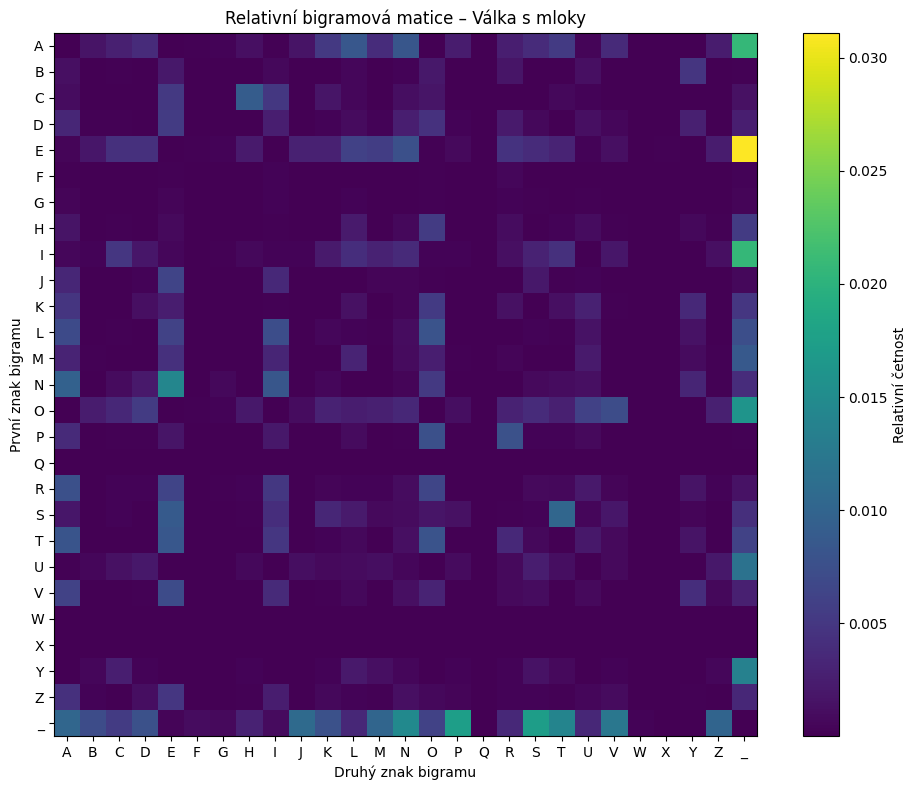

In [10]:
if plt is not None:
    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(saved_reference_matrix)
    ax.set_xticks(range(len(ALPHABET)))
    ax.set_yticks(range(len(ALPHABET)))
    ax.set_xticklabels(ALPHABET)
    ax.set_yticklabels(ALPHABET)
    ax.set_xlabel("Druhý znak bigramu")
    ax.set_ylabel("První znak bigramu")
    ax.set_title("Relativní bigramová matice – Válka s mloky")
    fig.colorbar(image, ax=ax, label="Relativní četnost")
    plt.tight_layout()
    plt.show()
else:
    print("Vizualizace byla přeskočena.")

Vizualizace slouží hlavně jako kontrola a názorné zobrazení jazykového modelu.

## 11. Vytvoření a kontrola klíče

Klíč musí být permutací všech 27 znaků abecedy. Pro reprodukovatelnou ukázku použijeme pevný seed.

In [11]:
demo_key = random_key(seed=42)
validate_key(demo_key)

print("Abeceda:", ALPHABET)
print("Klíč:   ", demo_key)
print("Délka klíče:", len(demo_key))
print("Obsahuje všechny znaky:", set(demo_key) == set(ALPHABET))

Abeceda: ABCDEFGHIJKLMNOPQRSTUVWXYZ_
Klíč:    QMJ_TGFKPWLSBOYNCRZEVHIXADU
Délka klíče: 27
Obsahuje všechny znaky: True


Validní klíč obsahuje každý znak abecedy právě jednou.

## 12. Šifrování a dešifrování

Zašifrujeme krátký text a stejným klíčem ho znovu dešifrujeme.

In [12]:
demo_plaintext = "AHOJ_SVETE_TOTO_JE_UKAZKA"
demo_ciphertext = substitute_encrypt(demo_plaintext, demo_key)
demo_decrypted = substitute_decrypt(demo_ciphertext, demo_key)

print("Plaintext: ", demo_plaintext)
print("Ciphertext:", demo_ciphertext)
print("Dešifrováno:", demo_decrypted)
print("Shoda:", demo_decrypted == demo_plaintext)

Plaintext:  AHOJ_SVETE_TOTO_JE_UKAZKA
Ciphertext: QKYWUZHTETUEYEYUWTUVLQDLQ
Dešifrováno: AHOJ_SVETE_TOTO_JE_UKAZKA
Shoda: True


Výsledek `True` potvrzuje, že šifrování a dešifrování používají vzájemně opačné mapování.

## 13. Výpočet věrohodnosti

Funkce `plausibility` vytvoří pozorovanou matici kandidátního textu pomocí:

```python
transition_matrix(get_bigrams(text))
```

Potom vypočítá součet log-pravděpodobností vážený četnostmi bigramů.

Vyšší, tedy méně záporné skóre obvykle znamená jazykově pravděpodobnější český text.

In [13]:
czech_like_text = clean_reference[:500]
random_text = "".join(random.Random(1).choices(ALPHABET, k=500))

czech_score = plausibility(czech_like_text, saved_reference_matrix)
random_score = plausibility(random_text, saved_reference_matrix)

print("Skóre českého úryvku:", czech_score)
print("Skóre náhodného textu:", random_score)
print("Český text má vyšší skóre:", czech_score > random_score)

Skóre českého úryvku: -8283.182718649747
Skóre náhodného textu: -7952.109251607248
Český text má vyšší skóre: False


Český úryvek by měl mít vyšší plausibility než náhodná posloupnost znaků.

## 14. Kontrola implementace `plausibility`

Pro kontrolu zobrazíme zdroj povinné funkce. Je vidět, že pozorovaná matice používá `transition_matrix`, jak požaduje pseudokód zadání.

In [14]:
print(inspect.getsource(plausibility))

def plausibility(text: str, TM_ref: np.ndarray) -> float:
    """Ohodnotí text podle referenčních četností bigramů."""
    reference = _validate_reference_matrix(TM_ref)
    observed = transition_matrix(get_bigrams(text))
    # Skóre je součet log-pravděpodobností bigramů vážený jejich četností v textu.
    return float(np.sum(np.log(reference) * observed))



Tím se potvrzuje, že nulové buňky jsou ošetřené také u matice kandidátního plaintextu.

## 15. Metropolis-Hastingsův algoritmus

V každé iteraci algoritmus:

1. prohodí dvě náhodné pozice v klíči,
2. dešifruje ciphertext kandidátním klíčem,
3. vypočítá nové skóre,
4. lepšího kandidáta přijme vždy,
5. horšího kandidáta přijme s pravděpodobností `0.01`,
6. samostatně si uchovává nejlepší nalezený výsledek.

Občasné přijetí horšího řešení pomáhá hledání uniknout z lokálního maxima.

In [15]:
print(inspect.signature(prolom_substitute))
print()
print(inspect.getsource(prolom_substitute))

(text: 'str', TM_ref: 'np.ndarray', iter: 'int', start_key: 'str | None' = None) -> 'tuple[str, str, float]'

def prolom_substitute(
    text: str,
    TM_ref: np.ndarray,
    iter: int,
    start_key: str | None = None,
) -> tuple[str, str, float]:
    """Prolomí substituční šifru jedním během Metropolis-Hastingsova algoritmu."""
    if iter < 0:
        raise ValueError("iter nesmí být záporné.")

    return _run_metropolis_hastings(
        text=text,
        TM_ref=TM_ref,
        iterations=iter,
        rng=random.Random(),
        start_key=start_key,
        progress_every=50,
    )



Povinný podpis funkce zůstává:

```python
prolom_substitute(text, TM_ref, iter, start_key=None)
```

## 16. Krátká demonstrační kryptoanalýza

Dlouhý finální běh používá 20 000 iterací pro každý učitelský ciphertext. V notebooku použijeme kratší ukázku, aby se dal rychle spustit.

Použijeme objektové API, pevný seed a vypneme lokální dolaďování.

In [16]:
cipher = SubstitutionCipher(saved_reference_matrix)

demo_source = clean_reference[:250]
demo_secret_key = random_key(seed=7)
demo_encrypted = cipher.encrypt(demo_source, demo_secret_key)

demo_result = cipher.crack(
    demo_encrypted,
    iterations=1_000,
    restarts=1,
    seed=1,
    polish=False,
    progress_every=0,
)

matching = sum(
    expected == actual
    for expected, actual in zip(demo_source, demo_result.plaintext)
)

print("Délka textu:", len(demo_source))
print("Shodné znaky:", matching)
print("Procento shody:", round(100 * matching / len(demo_source), 2), "%")
print("Plausibility:", demo_result.score)
print("Ukázka nalezeného textu:", demo_result.plaintext[:200])

Restart 1/1 nejlepší plausibility: -7334.087470188675
Celkově nejlepší restart: 1, plausibility: -7334.087470188675
Délka textu: 250
Shodné znaky: 166
Procento shody: 66.4 %
Plausibility: -7334.087470188675
Ukázka nalezeného textu: KDEJESTO_HLODALI_USTVYROK_TANA_PASA_NA_PAZO_NASLI_JESTO_MOM_ZVARO_NA_VURNIKY_KUYSOK_NA_BAZAD_UD_SYPATVE_ALO_KDEJESTO_SO_BOZTALI_NA_ZALYJO_LUDI_KANDUNG_JANDUONG_KAZITANA_M_RAN_TUCHA_CU_TU_MO_TAHLO_TANA


Krátký demonstrační běh nemusí obnovit celý plaintext. Jeho účelem je ukázat použití algoritmu, ne nahradit finální běh s 20 000 iteracemi.

## 17. Objektové API

Třída `SubstitutionCipher` je pohodlná fasáda nad stejnými povinnými funkcemi.

In [17]:
cipher_from_file = SubstitutionCipher.from_matrix_file(REFERENCE_MATRIX_PATH)

print("Typ objektu:", type(cipher_from_file).__name__)
print("Matice načtena:", cipher_from_file.reference_matrix is not None)
print("Shape matice:", cipher_from_file.reference_matrix.shape)
print("Skóre ukázkového textu:", cipher_from_file.score(clean_reference[:300]))

Typ objektu: SubstitutionCipher
Matice načtena: True
Shape matice: (27, 27)
Skóre ukázkového textu: -7504.698879844098


Objektové API nemění algoritmus. Pouze usnadňuje načtení matice, šifrování, dešifrování a kryptoanalýzu.

## 18. Zpracování jednoho a více souborů

Jeden soubor lze zpracovat metodou:

```python
cipher.crack_file(
    input_path,
    output_directory,
    iterations=20_000,
)
```

Všechny soubory lze zpracovat skriptem:

```powershell
python scripts\decrypt_samples.py `
  --matrix models\TM_ref.npy `
  --input-directory data\ciphertexts `
  --output-directory outputs `
  --iterations 20000 `
  --restarts 1 `
  --workers 4
```

Notebook tento dlouhý běh znovu nespouští. Následující buňka pouze zkontroluje již uložené výsledky.

In [18]:
plaintext_files = sorted(OUTPUT_DIR.glob("*_plaintext.txt"))
key_files = sorted(OUTPUT_DIR.glob("*_key.txt"))

print("Počet plaintext souborů:", len(plaintext_files))
print("Počet key souborů:", len(key_files))

invalid_keys = []
for path in key_files:
    key = path.read_text(encoding="utf-8").strip()
    try:
        validate_key(key)
    except ValueError:
        invalid_keys.append(path.name)

print("Neplatné klíče:", invalid_keys)

Počet plaintext souborů: 60
Počet key souborů: 60
Neplatné klíče: []


Finální odevzdání má obsahovat 60 plaintextů a 60 klíčů. Prázdný seznam neplatných klíčů potvrzuje správný výstupní formát.

## 19. Vyhodnocení známého učitelského příkladu

U souboru `text_1000_sample_1` známe správný plaintext a klíč.

Tyto známé soubory nebyly použity během hledání. Slouží pouze k následnému vyhodnocení dokončeného slepého běhu.

In [19]:
teacher_plaintext_path = (
    TEACHER_EXAMPLE_DIR / "text_1000_sample_1_plaintext.txt"
)
teacher_key_path = (
    TEACHER_EXAMPLE_DIR / "text_1000_sample_1_key.txt"
)
output_plaintext_path = (
    OUTPUT_DIR / "text_1000_sample_1_plaintext.txt"
)
output_key_path = (
    OUTPUT_DIR / "text_1000_sample_1_key.txt"
)

teacher_plaintext = teacher_plaintext_path.read_text(encoding="utf-8").strip()
teacher_key = teacher_key_path.read_text(encoding="utf-8").strip()
output_plaintext = output_plaintext_path.read_text(encoding="utf-8").strip()
output_key = output_key_path.read_text(encoding="utf-8").strip()

matching_chars = sum(
    expected == actual
    for expected, actual in zip(teacher_plaintext, output_plaintext)
)
matching_percent = 100 * matching_chars / len(teacher_plaintext)

print("Délka známého plaintextu:", len(teacher_plaintext))
print("Plaintext přesně sedí:", output_plaintext == teacher_plaintext)
print("Správné znaky:", matching_chars, "/", len(teacher_plaintext))
print("Procento shody:", round(matching_percent, 2), "%")
print("Key přesně sedí:", output_key == teacher_key)
print("Nalezený klíč je validní:", end=" ")
validate_key(output_key)
print(True)

Délka známého plaintextu: 1000
Plaintext přesně sedí: False
Správné znaky: 922 / 1000
Procento shody: 92.2 %
Key přesně sedí: False
Nalezený klíč je validní: True


V aktuálně uloženém finálním běhu bylo správně obnoveno **922 z 1000 znaků**, tedy **92,2 %**.

Celý plaintext ani celý klíč se přesně neshodují. To není porušení zadání, protože použitá kryptoanalýza je náhodná a bigramový model hodnotí pouze dvojice sousedních znaků. Zadání nevyžaduje stoprocentní úspěšnost.

## 20. Souhrn výsledků

Finální dávkové zpracování vytvořilo:

- 60 plaintext souborů,
- 60 souborů s klíčem,
- 0 chyb při zpracování.

Známý učitelský příklad dosáhl:

- 922 správných znaků z 1000,
- 92,2 % shodu,
- neúplnou shodu celého plaintextu,
- neúplnou shodu celého klíče.

Podrobný souhrn je uložen v:

```text
reports/evaluation_summary.md
reports/evaluation_summary.csv
```

In [20]:
evaluation_summary = PROJECT_ROOT / "reports" / "evaluation_summary.md"

print("Souhrn existuje:", evaluation_summary.exists())
if evaluation_summary.exists():
    print()
    print(evaluation_summary.read_text(encoding="utf-8")[:700])

Souhrn existuje: True

# Vyhodnocení výstupů

## Souhrn

- Počet plaintext souborů: 60
- Počet key souborů: 60
- Referenční matice: `models/TM_ref.npy`

## Učitelský příklad text_1000_sample_1

- Plaintext přesně sedí: False
- Správné znaky: 922
- Procento shody: 92.200000
- Key přesně sedí: False

## Tabulka

| length | sample_id | plaintext_file | key_file | plaintext_length | key_valid | plausibility | matches_teacher_example | matching_chars | matching_percent | key_matches_teacher_example |
|---:|---:|---|---|---:|---|---:|---|---:|---:|---|
| 1000 | 10 | text_1000_sample_10_plaintext.txt | text_1000_sample_10_key.txt | 1000 | True | -5177.713307 | N/A | N/A | N/A | N/A |
| 1000 | 11 | text_1000_sample_11_pla


## 21. Omezení řešení

Použité řešení má několik přirozených omezení:

- Metropolis-Hastingsův algoritmus je náhodný.
- Výsledky různých běhů se mohou lišit.
- Kratší ciphertexty obsahují méně bigramů.
- Bigramový model nehodnotí význam celých slov a vět.
- Nejvyšší plausibility nemusí odpovídat přesnému původnímu plaintextu.
- Pokud se některý znak v textu nevyskytne, část klíče nemusí být jednoznačně určitelná.
- Vyšší počet iterací a restartů může výsledek zlepšit, ale zvyšuje dobu výpočtu.

## 22. Závěr

Projekt splňuje hlavní kroky zadání:

- implementuje substituční šifrování a dešifrování,
- získává český referenční text z internetu,
- čistí text do abecedy `A-Z_`,
- vytváří a ukládá relativní bigramovou matici,
- hodnotí kandidátní plaintexty pomocí plausibility,
- hledá klíč Metropolis-Hastingsovým algoritmem,
- exportuje plaintext a klíč pro každý vstup,
- obsahuje notebook, report a automatické testy.

Bylo zpracováno všech 60 učitelských ciphertextů. U známého příkladu bylo obnoveno 922 z 1000 znaků, tedy 92,2 % textu.

Výsledek ukazuje, že jednoduchý bigramový model dokáže monoalfabetickou substituční šifru prolomit s vysokou úspěšností, ale nezaručuje přesné řešení při každém náhodném běhu.